In [1]:
from __future__ import annotations

import itertools
from dataclasses import dataclass
from functools import cached_property
from pathlib import Path
from typing import Literal

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn
import seaborn.objects as so
import skimage.morphology
from matplotlib import colors
from mpl_toolkits.axes_grid1 import ImageGrid
from scipy.optimize import least_squares
from skimage.io import imread
from skimage.metrics import structural_similarity
from tqdm.notebook import tqdm

from binlets import binlets
import zhang2018

tqdm.pandas()

## Dataset loader

In [2]:
@dataclass(kw_only=True)
class Images:
    """Loads a stack of images corresponding to sequential repetitions."""

    path: Path = ""
    name: str
    fov: int
    crop: Literal[0, 1, 2, 3] | None

    def __post_init__(self):
        self.path = Path(self.path, self.name, "raw", str(self.fov))
        self.files = sorted(self.path.glob("*.png"))
        if self.crop is None:
            self.slice = slice(None)
        else:
            self.slice = [
                (slice(None, 256), slice(None, 256)),
                (slice(256, None), slice(None, 256)),
                (slice(None, 256), slice(256, None)),
                (slice(256, None), slice(256, None)),
            ][self.crop]

    def __getitem__(self, i):
        return imread(self.files[i])[self.slice].astype(float)

    def __len__(self):
        return len(self.files)

    def load_stack(self):
        return np.stack([self[i] for i in range(len(self))])

    @cached_property
    def mean(self):
        """Mean of experiments."""
        return np.mean(self.load_stack(), axis=0)

    @cached_property
    def var(self):
        """Variance between experiments."""
        return np.var(self.load_stack(), axis=0)

## Metrics

In [3]:
def weighted_root_mean_squared_error(x, true_mean, true_var):
    """Weighted Mean Squared Error."""
    mask = true_var > 0
    return np.sqrt(np.mean((x[mask] - true_mean[mask]) ** 2 / true_var[mask]))


def weighted_mean_bias(x, true_mean, true_var):
    """Weighted Mean Bias."""
    mask = true_var > 0
    return np.mean((x[mask] - true_mean[mask]) / true_var[mask]**0.5)


def compute_metrics(image, ground_truth, ground_truth_var, *, data_range=256):
    return {
        "RMSE": weighted_root_mean_squared_error(image, ground_truth, ground_truth_var),
        "bias": weighted_mean_bias(image, ground_truth, ground_truth_var),
        "SSIM": structural_similarity(image, ground_truth, data_range=data_range),
        "total_intensity": np.sum(image),
        "mean_intensity": np.mean(image),
    }

## Methods

In [4]:
def poisson_binlets(image, *, sigma: float):
    def test(x, y):
        diff = x - y
        var = np.maximum(x, 0) + np.maximum(y, 0)
        return diff**2 <= sigma**2 * var

    return binlets(image[None], test=test, linear=False)[0]

In [5]:
device = "mps"
dncnn = zhang2018.get_dncnn_model(
    "pretrained/dncnn/checkpoints/model_epoch400.pth", device
)
n2n = zhang2018.get_unetn2n_model(
    "pretrained/n2n/checkpoints/model_epoch400.pth", device
)

init weight
model size: (556096, 17)


In [6]:
@dataclass(frozen=True, kw_only=True)
class Transform:
    offset: float
    slope: float

    def forward(self, image):
        return self.slope * (image - self.offset)

    def inverse(self, image):
        return image / self.slope + self.offset


def log_ratio(p, x):
    t = Transform(offset=p[0], slope=p[1])
    x = t.forward(x)
    return np.log(x.mean(0) / x.var(0)).ravel()


def fit_transform(images: Images) -> Transform:
    stack = images.load_stack()
    p = least_squares(log_ratio, x0=(3, 0.25), args=(stack,)).x
    return Transform(offset=p[0], slope=p[1])


images = Images(name="Confocal_BPAE_B", fov=1, crop=0)
transform = fit_transform(images)
transform

/var/folders/sp/0_8pxfjj4z3bw9rv8m2blnmw0000gn/T/ipykernel_26610/430948253.py:16: RuntimeWarning: invalid value encountered in log
  return np.log(x.mean(0) / x.var(0)).ravel()


Transform(offset=3.252512294286748, slope=0.28340350634114486)

In [7]:
def apply_methods(image, *, transform: Transform) -> dict[str, np.ndarray]:
    scale = zhang2018.Rescale()
    return {
        "raw": image,
        "binlets": transform.inverse(poisson_binlets(transform.forward(image), sigma=3)),
        "N2N": scale.inverse(n2n(scale.forward(image))),
        "DnCNN": scale.inverse(dncnn(scale.forward(image))),
    }

## Residuals

In [8]:
def set_border_xticks(ax: plt.Axes, lim=None, fontsize="small", **kwargs):
    if lim is None:
        lim = ax.get_xlim()
    ax.set_xticks(lim, lim, fontsize=fontsize, **kwargs)
    left, right = ax.get_xticklabels()
    left.set_horizontalalignment("left")
    right.set_horizontalalignment("right")


def set_border_yticks(ax: plt.Axes, lim=None, fontsize="small", **kwargs):
    if lim is None:
        lim = ax.get_ylim()
    ax.set_yticks(lim, lim, fontsize=fontsize, **kwargs)
    bottom, top = ax.get_yticklabels()
    bottom.set_verticalalignment("top")
    top.set_verticalalignment("bottom")

In [9]:
images = Images(name="Confocal_BPAE_B", fov=4, crop=0)

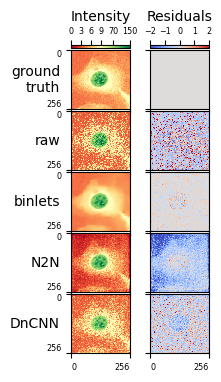

In [9]:
def plot_image_and_residuals(fig):
    images = Images(name="Confocal_BPAE_B", fov=4, crop=0)
    image = images[25]
    denoised = {
        "ground\ntruth": images.mean,
        **apply_methods(image, transform=transform),
    }
    residuals = {
        k: (v - images.mean) / np.sqrt(images.var) for k, v in denoised.items()
    }

    axes = ImageGrid(
        fig,
        111,
        (len(denoised), 2),
        axes_pad=(0.2, 0.02),
        cbar_mode="edge",
        cbar_location="top",
    )

    for ax, (name, im_d) in zip(axes.axes_row, denoised.items()):
        ax[0].set_ylabel(name, rotation=0, ha="right", va="center",labelpad=-10)
        int_im = ax[0].imshow(
            im_d,
            norm=colors.TwoSlopeNorm(vmin=0, vcenter=9, vmax=150),
            cmap="RdYlGn",
            interpolation="none",
            rasterized=True,
        )
        res_im = ax[1].imshow(
            residuals[name],
            norm=colors.CenteredNorm(0, 2),
            cmap="coolwarm",
            interpolation="none",
            rasterized=True,
        )

    for ax in axes.axes_column[0]:
        set_border_yticks(ax, lim=(0, 256), fontsize="xx-small")
    for ax in axes.axes_row[-1]:
        set_border_xticks(ax, lim=(0, 256), fontsize="xx-small")

    axes.cbar_axes[0].colorbar(
        int_im,
        label="Intensity",
        location="top",
        ticks=(0, 3, 6, 9, 70, 150),
    ).ax.tick_params(labelsize="xx-small")
    axes.cbar_axes[1].colorbar(
        res_im,
        label="Residuals",
        location="top",
        ticks=np.arange(-2, 3),
    ).ax.tick_params(labelsize="xx-small")
    fig.align_labels()


plot_image_and_residuals(plt.figure(figsize=(3, 4)))

## Compare

In [10]:
def segment(image, threshold=10):
    mask = image > threshold
    skimage.morphology.binary_opening(mask, skimage.morphology.disk(3), out=mask)
    skimage.morphology.remove_small_objects(mask, min_size=1000, out=mask)
    labels, num = skimage.morphology.label(mask, return_num=True)
    return labels, num


def yield_metrics(images: Images):
    labels, num = segment(images.mean)
    if num > 0:
        conditions = range(-2, num + 1)
    else:
        conditions = (-2,)
    for repeat, image in enumerate(images):
        denoised = apply_methods(image, transform=transform)
        denoised["ground_truth"] = images.mean
        # var = (denoised["raw"] - images.mean) ** 2
        var = images.var

        for label in conditions:
            if label == -2:
                label = "all"
                mask = slice(None)
            elif label == -1:
                label = "cells"
                mask = labels > 0
            else:
                mask = labels == label
                if label == 0:
                    label = "background"

            for method, image in denoised.items():
                yield {
                    "fov": images.fov,
                    "crop": images.crop,
                    "sample": repeat,
                    "object": str(label),
                    "method": method,
                    **compute_metrics(
                        image[mask],
                        images.mean[mask],
                        var[mask],
                    ),
                }


try:
    full = pd.read_parquet("full.parquet.gzip")
except FileNotFoundError:
    full = pd.DataFrame(
        itertools.chain.from_iterable(
            yield_metrics(images=Images(name="Confocal_BPAE_B", fov=fov, crop=crop))
            for fov, crop in tqdm(list(itertools.product(range(1, 21), range(4))))
        )
    )

    full = full.melt(
        id_vars=["fov", "crop", "sample", "object", "method"],
        value_vars=["RMSE", "bias", "SSIM", "total_intensity", "mean_intensity"],
        var_name="metric",
    )
    full.to_parquet("full.parquet.gzip", compression="gzip")

full.head()

,fov,crop,sample,object,method,metric,value
0,1,0,0,all,ground_truth,RMSE,0.000000
1,1,0,0,all,raw,RMSE,0.982006
2,1,0,0,all,Binlets,RMSE,0.231001
3,1,0,0,all,N2N,RMSE,1.195116
4,1,0,0,all,DNCNN,RMSE,0.710696


In [11]:
def normalize(x):
    if not x.metric.iloc[0] == "RMSE":
        return x
    return x.assign(value=x.set_index("method").value.loc["raw"] / x.value)


normalized = full.groupby(
    ["fov", "crop", "sample", "object", "metric"], group_keys=False
).progress_apply(normalize)

  0%|          | 0/102000 [00:00<?, ?it/s]

/var/folders/sp/0_8pxfjj4z3bw9rv8m2blnmw0000gn/T/ipykernel_18517/4168331958.py:11: FutureWarning: Passing a dict as an indexer is deprecated and will raise in a future version. Use a list instead.
  normalized.set_index("method")


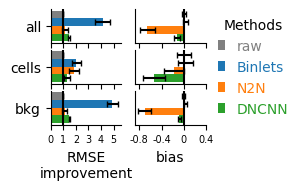

In [12]:
from scipy.stats import iqr


def plot_metrics(fig, normalized):
    axes = fig.subplots(nrows=3, ncols=2, sharex="col")
    metrics = {"RMSE": axes[:, 0], "bias": axes[:, 1]}  # , "SSIM": axes[:, 2]}
    objects = ["all", "cells", "background"]
    methods = {"raw": "gray", "Binlets": "C0", "N2N": "C1", "DNCNN": "C2"}

    results = (
        normalized.set_index("method")
        .drop("ground_truth")
        .reset_index()
        .set_index("object")
        .loc[objects]
        .reset_index()
        .set_index("metric")
        .loc[metrics]
        .reset_index()
        .groupby(["metric", "object", "method"])
        .value
        # .agg(["mean", "std"])
        .agg(["median", iqr])
    )

    ylabel = {
        "background": "bkg",
        "cells": "cells",
        "all": "all",
    }
    xlabel = {
        "RMSE": "RMSE\nimprovement",
        "bias": "bias",
    }

    bar_width = 0.15
    for metric, axcol in metrics.items():
        axcol[-1].set(xlabel=xlabel[metric])
        for ax, object in zip(axcol, objects):
            for j, (method, color) in enumerate(methods.items()):
                data = results.loc[(metric, object, method)]
                ax.barh(
                    bar_width * (1 - j),
                    height=bar_width,
                    width="median",
                    xerr="iqr",
                    align="edge",
                    data=data,
                    capsize=2,
                    color=color,
                )

    axes[1, -1].legend(
        methods,
        bbox_to_anchor=(1, 0.5),
        loc="center left",
        frameon=False,
        title="Methods",
        labelcolor="linecolor",
        handlelength=0.5,
    )

    for ax in metrics["RMSE"]:
        ax.axvline(1, color="black")
    for ax in metrics["bias"]:
        ax.axvline(0, color="black")
    for ax in axes.flat:
        ax.set_yticks(())
    for ax, name in zip(axes[:, 0], objects):
        ax.set_yticks((0,), (ylabel[name],))

    seaborn.despine(fig)
    for ax, ticks in zip(axes[-1], [np.arange(6), [-0.8, -0.4, 0, 0.4]]):
        ax.set_xticks(ticks, ticks, fontsize="x-small")


plot_metrics(plt.figure(figsize=(2, 1.5)), normalized=normalized)

## Intensity

In [13]:
def drop_from(df, column: str, labels: list):
    return (
        df.set_index(column, append=True)
        .drop(index=labels, level=column)
        .reset_index(column)
    )


def residuals(x: pd.DataFrame):
    gt = x.set_index("method").value.loc["ground_truth"].iloc[0]
    return x.assign(value=x.value.where(x.method == "ground_truth", 1 - x.value / gt))


intensity = (
    full.pipe(drop_from, column="object", labels=["all", "cells", "background"])
    .pipe(drop_from, column="metric", labels=["RMSE", "bias", "SSIM"])
    .groupby(["fov", "crop", "object", "metric"], group_keys=False)
    .apply(residuals)
)

intensity_summary = intensity.groupby(
    ["method", "metric", "fov", "crop", "object"]
).value.agg([np.mean, np.std])
intensity_summary = (
    intensity_summary.drop("ground_truth")
    .join(intensity_summary.loc["ground_truth", "mean"].rename("ground_truth"))
    .droplevel(["fov", "crop", "object"])
)

intensity_summary = (
    intensity_summary.drop("total_intensity").loc["mean_intensity"].drop("raw")
)

intensity_summary.head()

,mean,std,ground_truth
method,,,
Binlets,0.003675,0.017900,54.394908
DNCNN,0.175488,0.016814,54.394908
N2N,0.048135,0.017907,54.394908
Binlets,0.004063,0.010916,47.250054
DNCNN,0.187533,0.008391,47.250054


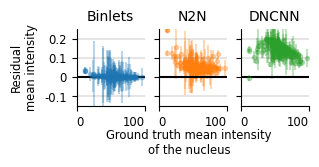

In [14]:
def plot_intensity_metric(fig):
    methods = {
        "Binlets": "C0",
        "N2N": "C1",
        "DNCNN": "C2",
    }

    axes = fig.subplots(
        ncols=len(methods), sharey=True, sharex=True, gridspec_kw=dict(hspace=0.5)
    )
    seaborn.despine(fig)

    fig.supxlabel("Ground truth mean intensity\nof the nucleus", y=-0.4, fontsize="small")
    fig.supylabel("Residual\nmean intensity", fontsize="small", x=-0.05, ha='center')
    axes[0].set_yticks([-0.1, 0, 0.1, 0.2], [-0.1, 0, 0.1, 0.2], fontsize="small")
    axes[0].set_ylim(-0.15, 0.25)
    axes[0].set_xlim(0, 100)
    for ax, method in zip(axes, methods):
        ax.set_title(method, fontsize="medium")
        set_border_xticks(ax, (0, 100))

    for ax, (method, color) in zip(axes, methods.items()):
        ax.errorbar(
            x="ground_truth",
            y="mean",
            yerr="std",
            data=intensity_summary.loc[method],
            fmt=".",
            alpha=0.3,
            color=color,
        )
        ax.axhline(0, color="black")
        for y in (-0.1, 0.1, 0.2):
            ax.axhline(y, color="black", alpha=0.1)


plot_intensity_metric(plt.figure(figsize=(3, 1)))

## Plot figure

/var/folders/sp/0_8pxfjj4z3bw9rv8m2blnmw0000gn/T/ipykernel_18517/4168331958.py:11: FutureWarning: Passing a dict as an indexer is deprecated and will raise in a future version. Use a list instead.
  normalized.set_index("method")


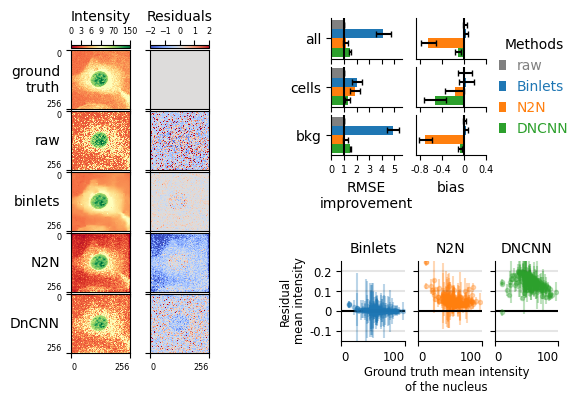

In [15]:
fig = plt.figure(figsize=(6, 4))

gs = fig.add_gridspec(
    nrows=4,
    ncols=4,
    width_ratios=[1.5, 0.1, 1, 0.4],
    height_ratios=[1.2, 0.5, 0.7, 0.3],
)
figs = [
    fig.add_subfigure(gs[:, 0]),
    fig.add_subfigure(gs[0, -2]),
    fig.add_subfigure(gs[-2, -2:]),
]

plot_image_and_residuals(figs[0])
plot_metrics(fig=figs[1], normalized=normalized)
plot_intensity_metric(fig=figs[2])

path = "../../../article/figures/6_zhang2018"
fig.savefig(path + ".png", bbox_inches="tight")
fig.savefig(path + ".pdf", bbox_inches="tight")

## Version 2

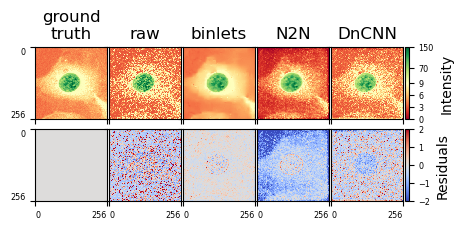

In [20]:
def plot_image_and_residuals(fig):
    images = Images(name="Confocal_BPAE_B", fov=4, crop=0)
    image = images[25]
    denoised = {
        "ground\ntruth": images.mean,
        **apply_methods(image, transform=transform),
    }
    residuals = {
        k: (v - images.mean) / np.sqrt(images.var) for k, v in denoised.items()
    }

    axes = ImageGrid(
        fig,
        111,
        (2, len(denoised)),
        axes_pad=(0.02, 0.1),
        cbar_mode="edge",
        cbar_location="right",
    )

    for ax, (name, im_d) in zip(axes.axes_column, denoised.items()):
        ax[0].set_title(name)
        int_im = ax[0].imshow(
            im_d,
            norm=colors.TwoSlopeNorm(vmin=0, vcenter=9, vmax=150),
            cmap="RdYlGn",
            interpolation="none",
            rasterized=True,
        )
        res_im = ax[1].imshow(
            residuals[name],
            norm=colors.CenteredNorm(0, 2),
            cmap="coolwarm",
            interpolation="none",
            rasterized=True,
        )

    for ax in axes.axes_column[0]:
        set_border_yticks(ax, lim=(0, 256), fontsize="xx-small")
    for ax in axes.axes_row[-1]:
        set_border_xticks(ax, lim=(0, 256), fontsize="xx-small")

    axes.cbar_axes[0].colorbar(
        int_im,
        label="Intensity",
        location="right",
        ticks=(0, 3, 6, 9, 70, 150),
    ).ax.tick_params(labelsize="xx-small")
    axes.cbar_axes[1].colorbar(
        res_im,
        label="Residuals",
        location="right",
        ticks=np.arange(-2, 3),
    ).ax.tick_params(labelsize="xx-small")
    fig.align_labels()


plot_image_and_residuals(plt.figure(figsize=(6, 2)))

/var/folders/sp/0_8pxfjj4z3bw9rv8m2blnmw0000gn/T/ipykernel_18517/1550021800.py:11: FutureWarning: Passing a dict as an indexer is deprecated and will raise in a future version. Use a list instead.
  normalized.set_index("method")


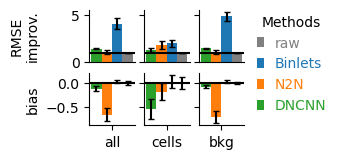

In [58]:
from scipy.stats import iqr


def plot_metrics(fig, normalized):
    axes = fig.subplots(nrows=2, ncols=3, sharey="row")
    metrics = {"RMSE": axes[0], "bias": axes[1]}  # , "SSIM": axes[:, 2]}
    objects = ["all", "cells", "background"]
    methods = {"raw": "gray", "Binlets": "C0", "N2N": "C1", "DNCNN": "C2"}

    results = (
        normalized.set_index("method")
        .drop("ground_truth")
        .reset_index()
        .set_index("object")
        .loc[objects]
        .reset_index()
        .set_index("metric")
        .loc[metrics]
        .reset_index()
        .groupby(["metric", "object", "method"])
        .value
        # .agg(["mean", "std"])
        .agg(["median", iqr])
    )

    xlabel = {
        "background": "bkg",
        "cells": "cells",
        "all": "all",
    }
    ylabel = {
        "RMSE": "RMSE\nimprov.",
        "bias": "bias",
    }

    bar_width = 0.15
    for metric, axcol in metrics.items():
        axcol[0].set(ylabel=ylabel[metric])
        for ax, object in zip(axcol, objects):
            for j, (method, color) in enumerate(methods.items()):
                data = results.loc[(metric, object, method)]
                ax.bar(
                    bar_width * (1 - j),
                    height="median",
                    width=bar_width,
                    yerr="iqr",
                    align="edge",
                    data=data,
                    capsize=2,
                    color=color,
                )

    axes[1, -1].legend(
        methods,
        bbox_to_anchor=(1, 0),
        loc="lower left",
        frameon=False,
        title="Methods",
        labelcolor="linecolor",
        handlelength=0.5,
    )

    for ax in metrics["RMSE"]:
        ax.axhline(1, color="black")
    for ax in metrics["bias"]:
        ax.axhline(0, color="black")
    for ax in axes.flat:
        ax.set_xticks(())
    for ax, name in zip(axes[-1], objects):
        ax.set_xticks((0,), (xlabel[name],))

    seaborn.despine(fig)
    fig.align_labels()
    # for ax, ticks in zip(axes[-1], [np.arange(6), [-0.8, -0.4, 0, 0.4]]):
        # ax.set_xticks(ticks, ticks, fontsize="x-small")


plot_metrics(plt.figure(figsize=(2, 1.5)), normalized=normalized)

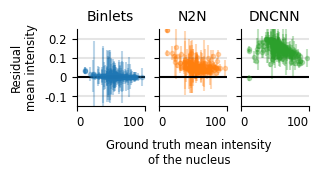

In [77]:
def plot_intensity_metric(fig, x, y):
    methods = {
        "Binlets": "C0",
        "N2N": "C1",
        "DNCNN": "C2",
    }

    axes = fig.subplots(
        ncols=len(methods), sharey=True, sharex=True, gridspec_kw=dict(hspace=0.5)
    )
    seaborn.despine(fig)

    fig.supxlabel("Ground truth mean intensity\nof the nucleus", y=y, fontsize="small")
    fig.supylabel("Residual\nmean intensity", fontsize="small", x=x, ha='center')
    axes[0].set_yticks([-0.1, 0, 0.1, 0.2], [-0.1, 0, 0.1, 0.2], fontsize="small")
    axes[0].set_ylim(-0.15, 0.25)
    axes[0].set_xlim(0, 100)
    for ax, method in zip(axes, methods):
        ax.set_title(method, fontsize="medium")
        set_border_xticks(ax, (0, 100))

    for ax, (method, color) in zip(axes, methods.items()):
        ax.errorbar(
            x="ground_truth",
            y="mean",
            yerr="std",
            data=intensity_summary.loc[method],
            fmt=".",
            alpha=0.3,
            color=color,
        )
        ax.axhline(0, color="black")
        for y in (-0.1, 0.1, 0.2):
            ax.axhline(y, color="black", alpha=0.1)


plot_intensity_metric(plt.figure(figsize=(3, 1)), x=-0.05, y=-0.5)

/var/folders/sp/0_8pxfjj4z3bw9rv8m2blnmw0000gn/T/ipykernel_18517/1550021800.py:11: FutureWarning: Passing a dict as an indexer is deprecated and will raise in a future version. Use a list instead.
  normalized.set_index("method")


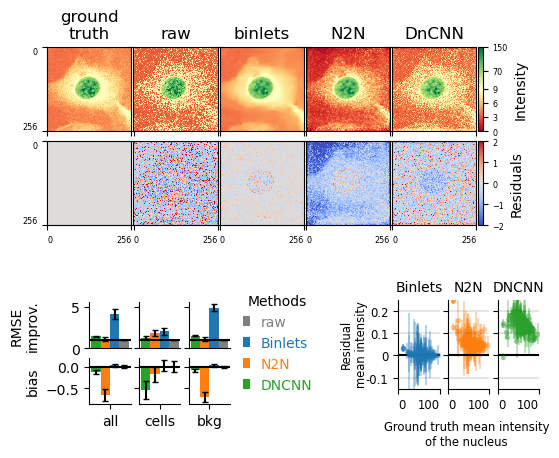

In [89]:
fig = plt.figure(figsize=(6, 4))

gs = fig.add_gridspec(
    nrows=4,
    ncols=4,
    height_ratios=[2, 0.3, 1, 0.15],
    width_ratios=[0.6, 1, 0.7, 1],
)
figs = [
    fig.add_subfigure(gs[0, :]),
    fig.add_subfigure(gs[-2:, 1]),
    fig.add_subfigure(gs[-2, -1]),
]

plot_image_and_residuals(figs[0])
plot_metrics(fig=figs[1], normalized=normalized)
plot_intensity_metric(fig=figs[2], x=-0.12, y=-0.4)

path = "../../../article/figures/6_zhang2018"
fig.savefig(path + ".png", bbox_inches="tight")
fig.savefig(path + ".pdf", bbox_inches="tight")